In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import os

BASE_PATH = "/content/drive/MyDrive/modelo_IA"

print("📁 Verificando dataset...")
for clase in ['gatos', 'perros', 'humanos']:
    path = os.path.join(BASE_PATH, clase)
    if os.path.exists(path):
        num_imgs = len([f for f in os.listdir(path) if f.endswith(('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'))])
        print(f"✅ {clase}: {num_imgs} imágenes")
    else:
        print(f"❌ {clase}: NO ENCONTRADA")

📁 Verificando dataset...
✅ gatos: 70 imágenes
✅ perros: 60 imágenes
✅ humanos: 158 imágenes


In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BASE_PATH = "/content/drive/MyDrive/modelo_IA"
IMG_SIZE = 224
BATCH = 16

datagen = ImageDataGenerator(
    rescale=1/255.0,
    validation_split=0.2
)

train = datagen.flow_from_directory(
    BASE_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode='categorical',
    subset='training'
)

val = datagen.flow_from_directory(
    BASE_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode='categorical',
    subset='validation'
)

print(f"\n📊 Clases: {train.class_indices}")
print(f"📊 Entrenamiento: {train.samples} imágenes")
print(f"📊 Validación: {val.samples} imágenes")

Found 239 images belonging to 3 classes.
Found 59 images belonging to 3 classes.

📊 Clases: {'gatos': 0, 'humanos': 1, 'perros': 2}
📊 Entrenamiento: 239 imágenes
📊 Validación: 59 imágenes


In [15]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
print("🚀 Entrenando...")

history = model.fit(
    train,
    validation_data=val,
    epochs=10
)

print("✅ Listo")

🚀 Entrenando...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.6576 - loss: 0.6723 - val_accuracy: 1.0000 - val_loss: 0.0296
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 750ms/step - accuracy: 0.9963 - loss: 0.0182 - val_accuracy: 1.0000 - val_loss: 0.0182
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 712ms/step - accuracy: 0.9982 - loss: 0.0073 - val_accuracy: 0.9831 - val_loss: 0.0203
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 800ms/step - accuracy: 0.9978 - loss: 0.0056 - val_accuracy: 1.0000 - val_loss: 0.0175
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 792ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.9831 - val_loss: 0.0262
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 780ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 1.0000 - val_loss: 0.0105
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 808ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 0.0117
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 713ms/step - accuracy: 1.0000 - loss: 8.3397e-04 - val_acc

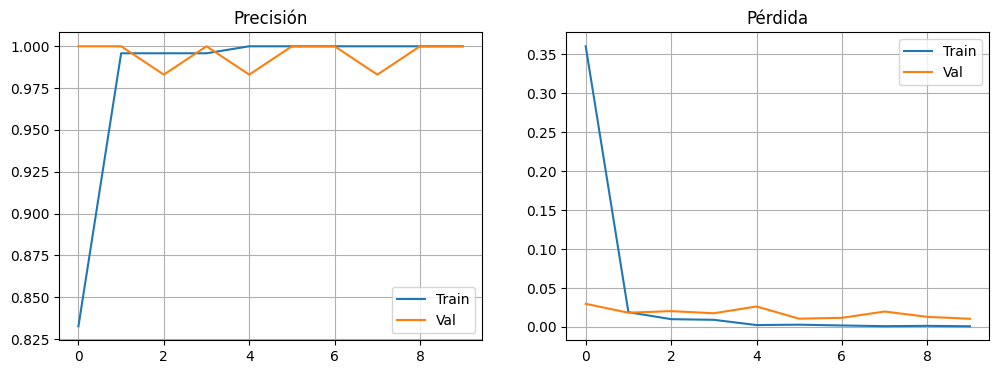

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Precisión')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Pérdida')
plt.legend()
plt.grid(True)

plt.show()

In [22]:
BASE_PATH = "/content/drive/MyDrive/modelo_IA"
model.save(f"{BASE_PATH}/modelo_clasificador.h5")
print(f"✅ Modelo guardado en: {BASE_PATH}/modelo_clasificador.h5")

✅ Modelo guardado en: /content/drive/MyDrive/modelo_IA/modelo_clasificador.h5


In [20]:
!pip install tensorflowjs -q
print("✅ TensorFlow.js instalado")

✅ TensorFlow.js instalado


In [23]:
!tensorflowjs_converter \
    --input_format=keras \
    /content/drive/MyDrive/modelo_IA/modelo_clasificador.h5 \
    /content/drive/MyDrive/modelo_IA/tfjs_model

print("✅ Modelo convertido a TensorFlow.js")

2025-12-03 21:19:29.222267: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764796769.299683    4972 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764796769.324638    4972 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764796769.390276    4972 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764796769.390358    4972 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764796769.390369    4972 computation_placer.cc:177] computation placer alr

In [24]:
import os

BASE_PATH = "/content/drive/MyDrive/modelo_IA"
tfjs_path = f"{BASE_PATH}/tfjs_model"

print("📁 Archivos generados en tfjs_model:")
for file in sorted(os.listdir(tfjs_path)):
    size = os.path.getsize(f"{tfjs_path}/{file}") / (1024*1024)
    print(f"  📄 {file} ({size:.2f} MB)")

📁 Archivos generados en tfjs_model:
  📄 group1-shard1of3.bin (4.00 MB)
  📄 group1-shard2of3.bin (4.00 MB)
  📄 group1-shard3of3.bin (1.24 MB)
  📄 model.json (0.15 MB)


In [25]:
import json

BASE_PATH = "/content/drive/MyDrive/modelo_IA"

with open(f"{BASE_PATH}/clases.json", 'w') as f:
    json.dump(train.class_indices, f, indent=2)

print("✅ Archivo clases.json guardado")

# Mostrar contenido
with open(f"{BASE_PATH}/clases.json", 'r') as f:
    print("\n📋 Contenido:")
    print(f.read())

✅ Archivo clases.json guardado

📋 Contenido:
{
  "gatos": 0,
  "humanos": 1,
  "perros": 2
}


In [26]:
import os

BASE_PATH = "/content/drive/MyDrive/modelo_IA"

print("\n" + "="*60)
print("🎉 ¡PROCESO COMPLETADO EXITOSAMENTE!")
print("="*60)
print(f"\n📂 Ubicación: {BASE_PATH}")
print("\n📦 Archivos generados:")
print("  ✅ modelo_clasificador.h5 (9.24 MB)")
print("  ✅ tfjs_model/ (carpeta con 4 archivos)")
print("  ✅ clases.json")
print("\n💾 Total del modelo web: ~9.39 MB")
print("\n💡 Para usar en tu app web:")
print("  1. Descarga la carpeta 'tfjs_model'")
print("  2. Descarga 'clases.json'")
print("  3. Cárgalos con TensorFlow.js")


🎉 ¡PROCESO COMPLETADO EXITOSAMENTE!

📂 Ubicación: /content/drive/MyDrive/modelo_IA

📦 Archivos generados:
  ✅ modelo_clasificador.h5 (9.24 MB)
  ✅ tfjs_model/ (carpeta con 4 archivos)
  ✅ clases.json

💾 Total del modelo web: ~9.39 MB

💡 Para usar en tu app web:
  1. Descarga la carpeta 'tfjs_model'
  2. Descarga 'clases.json'
  3. Cárgalos con TensorFlow.js
